In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import statsmodels.formula.api as smf
import statsmodels.stats.diagnostic as smd
from statsmodels.stats.stattools import jarque_bera
from itertools import permutations
from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = 'analysis_output_v5/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--', 'font.size': 11,
})

BRAND_COLOR = {'Richeese': '#378ADD', 'Richoco': '#D4537E', 'Nextar': '#1D9E75'}
CAT_COLOR   = {
    'Wafer': '#378ADD', 'Kue/Pie': '#1D9E75', 'Minuman': '#D4537E',
    'Mi Instan': '#BA7517', 'Extruded Snack': '#534AB7', 'Biskuit': '#888780',
}

print('✅ Config selesai')
print(f'   Output dir : {OUTPUT_DIR}')


c:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


✅ Config selesai
   Output dir : analysis_output_v5/


In [4]:
# Sesuaikan path ke lokasi file dataset v5
DATA_PATH = 'cannibalization_output/simulated_dataset_v5.csv'

df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'])
df['Week'] = pd.to_datetime(df['Week'])

print(f'✅ Dataset loaded')
print(f'   Shape      : {df.shape}')
print(f'   Date range : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'   Unique SKU : {df["SKU_ID"].nunique()}')
print(f'   Branches   : {sorted(df["Branch"].unique())}')
print(f'   Kolom      : {df.columns.tolist()}')
print(f'\nIsPromo distribution:')
print((df['IsPromo'].value_counts(normalize=True)*100).round(1))
print(f'\nPromo days % per SKU:')
print((df.groupby('SKU_ID')['IsPromo'].mean()*100).round(1))


✅ Dataset loaded
   Shape      : (58480, 15)
   Date range : 2024-01-01 → 2025-12-31
   Unique SKU : 20
   Branches   : ['Bandung', 'Jakarta', 'Semarang', 'Surabaya']
   Kolom      : ['Date', 'Year', 'Month', 'Week', 'Branch', 'SKU_ID', 'SKU_Name', 'SKU_Category', 'Brand', 'NormalPrice', 'DiscountedPrice', 'DiscountPercentage', 'IsPromo', 'Qty', 'Revenue']

IsPromo distribution:
IsPromo
0    71.8
1    28.2
Name: proportion, dtype: float64

Promo days % per SKU:
SKU_ID
S001    26.9
S002    29.1
S003    30.1
S004    30.6
S005    26.0
S006    30.4
S007    28.2
S008    31.7
S009    29.4
S010    27.5
S011    27.5
S012    27.5
S013    26.3
S014    25.9
S015    27.8
S016    24.4
S017    28.9
S018    28.0
S019    29.7
S020    28.2
Name: IsPromo, dtype: float64


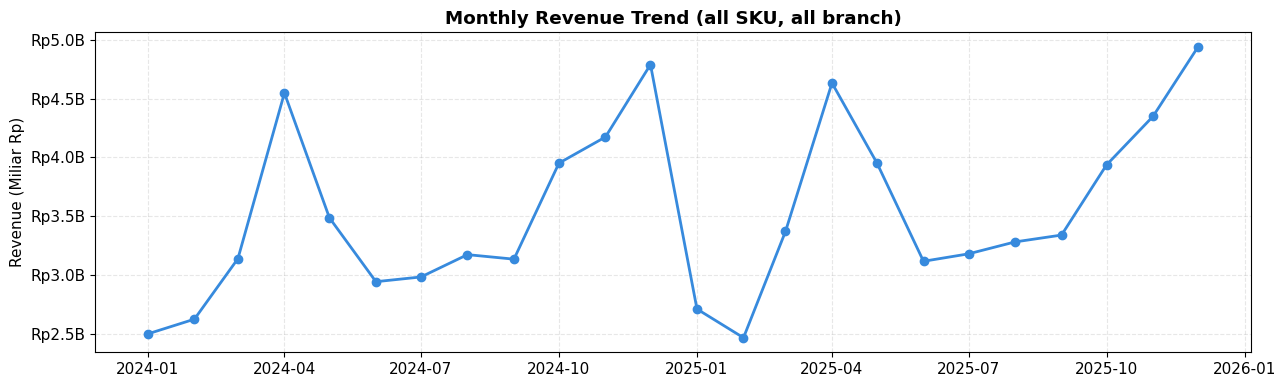

✅ Saved: monthly_trend_1.png


In [5]:
# Monthly revenue trend
monthly = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly['Date'], monthly['Revenue']/1e9, marker='o', linewidth=2, color='#378ADD')
ax.set_title('Monthly Revenue Trend (all SKU, all branch)', fontweight='bold')
ax.set_ylabel('Revenue (Miliar Rp)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'Rp{x:.1f}B'))
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: monthly_trend_1.png')

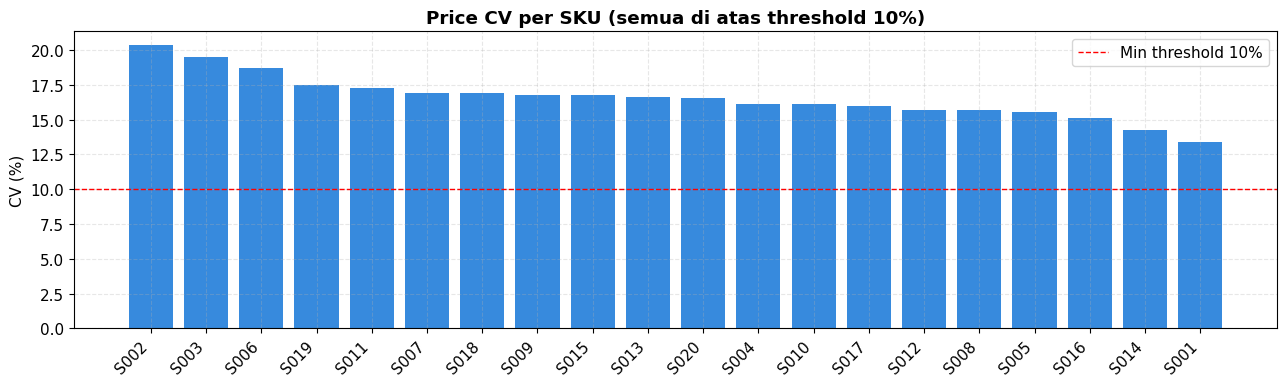

=== Price CV per SKU ===
SKU_ID  cv_pct
  S002   20.34
  S003   19.50
  S006   18.71
  S019   17.47
  S011   17.26
  S007   16.95
  S018   16.93
  S009   16.81
  S015   16.77
  S013   16.60
  S020   16.56
  S004   16.13
  S010   16.10
  S017   16.00
  S012   15.71
  S008   15.70
  S005   15.57
  S016   15.14
  S014   14.27
  S001   13.41


In [6]:
# Price CV per SKU
cv = df.groupby(['SKU_ID'])['DiscountedPrice'].agg(['mean','std'])
cv['cv_pct'] = (cv['std']/cv['mean']*100).round(2)
cv = cv.sort_values('cv_pct', ascending=False).reset_index()

fig, ax = plt.subplots(figsize=(13, 4))
colors = [('#D4537E' if v < 10 else '#378ADD') for v in cv['cv_pct']]
ax.bar(cv['SKU_ID'], cv['cv_pct'], color=colors)
ax.axhline(10, color='red', linestyle='--', linewidth=1, label='Min threshold 10%')
ax.set_title('Price CV per SKU (semua di atas threshold 10%)', fontweight='bold')
ax.set_ylabel('CV (%)')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '02_price_cv.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Price CV per SKU ===')
print(cv[['SKU_ID','cv_pct']].to_string(index=False))


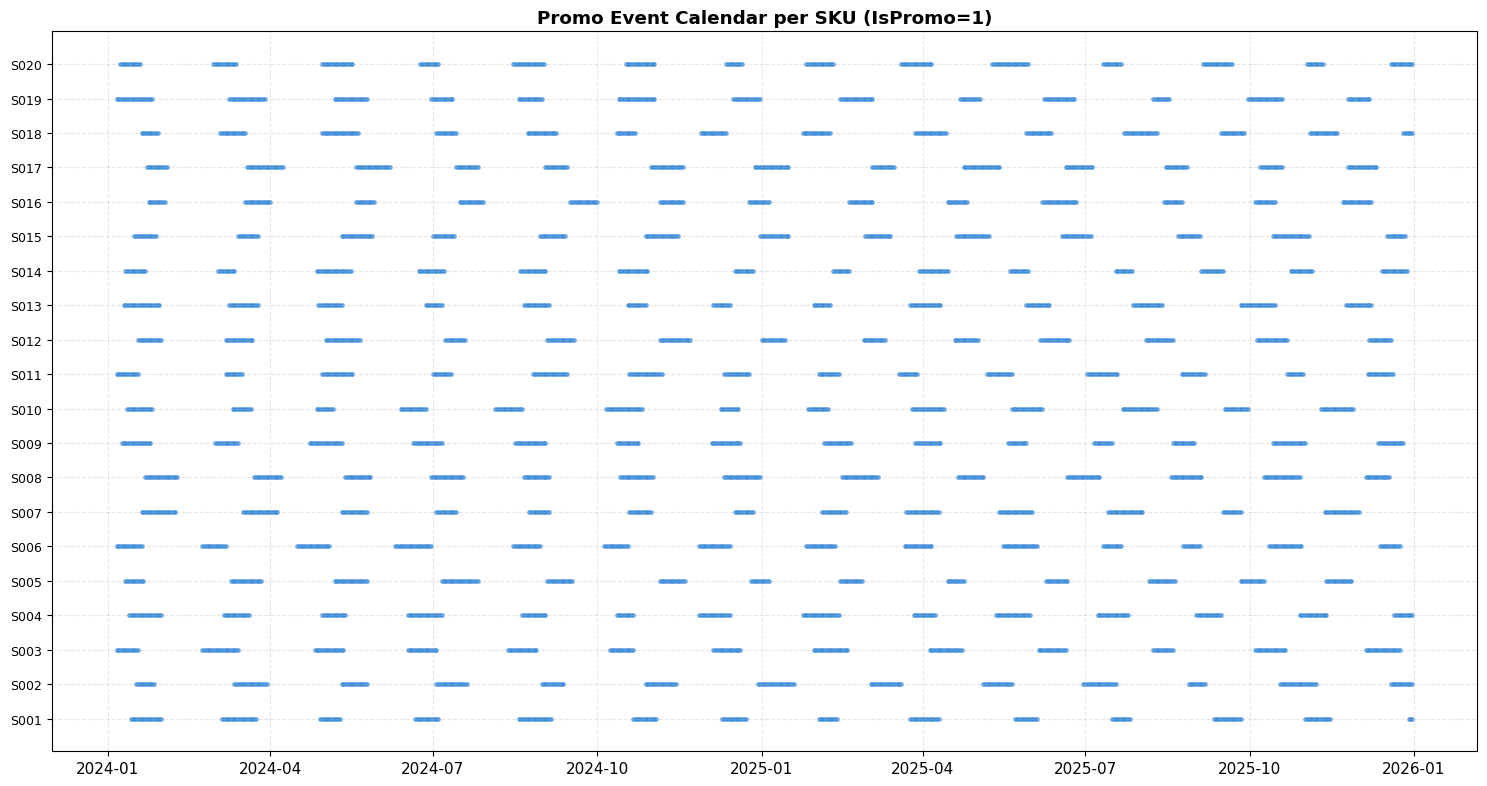

✅ Saved: promo_calendar_3.png


In [7]:
# Promo event calendar — visualisasi per SKU (binary IsPromo)
promo_df = df[df['IsPromo']==1][['Date','SKU_ID']].drop_duplicates()
skus_sorted = sorted(df['SKU_ID'].unique())

fig, ax = plt.subplots(figsize=(15, 8))
for i, sku in enumerate(skus_sorted):
    sku_promo = promo_df[promo_df['SKU_ID']==sku]
    ax.scatter(sku_promo['Date'], [i]*len(sku_promo), color='#378ADD', s=6, alpha=0.6)

ax.set_yticks(range(len(skus_sorted)))
ax.set_yticklabels(skus_sorted, fontsize=9)
ax.set_title('Promo Event Calendar per SKU (IsPromo=1)', fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '03_promo_calendar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: promo_calendar_3.png')


In [8]:
df['month_num'] = (df['Year'] - 2024) * 12 + df['Month']
df['log_qty']   = np.log(df['Qty'] + 1)

qty_wide  = df.pivot_table(index=['Date','Branch'], columns='SKU_ID', values='log_qty')
disc_wide = df.pivot_table(index=['Date','Branch'], columns='SKU_ID', values='DiscountPercentage')
meta_wide = df.groupby(['Date','Branch'])[['month_num','Year']].first()

sku_cat   = df.groupby('SKU_ID')['SKU_Category'].first().to_dict()
sku_brand = df.groupby('SKU_ID')['Brand'].first().to_dict()
sku_name  = df.groupby('SKU_ID')['SKU_Name'].first().to_dict()

print(f'qty_wide shape  : {qty_wide.shape}')
print(f'disc_wide shape : {disc_wide.shape}')
print(f'N obs per branch: {df.groupby("Branch").size().iloc[0] // df["SKU_ID"].nunique()} hari')


qty_wide shape  : (2924, 20)
disc_wide shape : (2924, 20)
N obs per branch: 731 hari


In [9]:
results = []

for cat in sorted(df['SKU_Category'].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2: continue

    for sku_a, sku_b in permutations(skus, 2):
        try:
            reg_df = pd.DataFrame({
                'log_qty_B' : qty_wide[sku_b],
                'disc_pct_A': disc_wide[sku_a],
                'disc_pct_B': disc_wide[sku_b],
            }).join(meta_wide).reset_index().dropna()

            if len(reg_df) < 100: continue

            model = smf.ols(
                'log_qty_B ~ disc_pct_A + disc_pct_B + month_num + C(Branch) + C(Year)',
                data=reg_df
            ).fit()

            coef = model.params.get('disc_pct_A')
            pval = model.pvalues.get('disc_pct_A')
            if coef is None: continue

            residuals   = model.resid
            _, _, skew, _= jarque_bera(residuals)
            bp          = smd.het_breuschpagan(residuals, model.model.exog)
            cv_a        = (disc_wide[sku_a].std() / disc_wide[sku_a].mean() * 100
                           if disc_wide[sku_a].mean() != 0 else 0)

            norm_flag   = 'PASS' if abs(skew) < 1.0 else f'WARN: skew={skew:.2f}'
            hetero_flag = 'PASS' if bp[1] > 0.01 else f'WARN: p={bp[1]:.3f}'
            cv_flag     = 'PASS' if cv_a >= 10 else f'WARN: CV={cv_a:.1f}%'
            reliability = 'RELIABLE' if all('WARN' not in f for f in [norm_flag, hetero_flag, cv_flag]) else 'UNRELIABLE'

            verdict = ('Tidak Signifikan' if pval >= 0.05
                       else 'CANNIBALIZATION' if coef < 0 else 'KOMPLEMEN')

            results.append({
                'SKU_Category': cat,
                'SKU_A': sku_a, 'SKU_A_Name': sku_name[sku_a], 'Brand_A': sku_brand[sku_a],
                'SKU_B': sku_b, 'SKU_B_Name': sku_name[sku_b], 'Brand_B': sku_brand[sku_b],
                'coef_disc_A': round(coef, 4), 'p_value': round(pval, 4),
                'r_squared': round(model.rsquared, 4), 'n_obs': len(reg_df),
                'cv_disc_A': round(cv_a, 2), 'skew': round(skew, 3),
                'norm_flag': norm_flag, 'hetero_flag': hetero_flag, 'cv_flag': cv_flag,
                'reliability': reliability, 'verdict': verdict,
            })
        except: continue

results_df = pd.DataFrame(results)
reliable   = results_df[results_df['reliability']=='RELIABLE']

print('=== VERDICT SUMMARY (RELIABLE only) ===')
print(reliable['verdict'].value_counts())
print(f'\nTotal pasangan : {len(results_df)}')
print(f'RELIABLE       : {len(reliable)}')
print(f'UNRELIABLE     : {len(results_df) - len(reliable)}')

print('\n=== VERDICT SUMMARY (ALL, untuk referensi) ===')
print(results_df['verdict'].value_counts())

results_df.to_csv(OUTPUT_DIR + 'cannibalization_results.csv', index=False)
print('\n✅ Saved: cannibalization_results_v5.csv')


=== VERDICT SUMMARY (RELIABLE only) ===
verdict
Tidak Signifikan    9
CANNIBALIZATION     8
KOMPLEMEN           4
Name: count, dtype: int64

Total pasangan : 58
RELIABLE       : 21
UNRELIABLE     : 37

=== VERDICT SUMMARY (ALL, untuk referensi) ===
verdict
Tidak Signifikan    25
CANNIBALIZATION     23
KOMPLEMEN           10
Name: count, dtype: int64

✅ Saved: cannibalization_results_v5.csv


In [10]:
print('=== CANNIBALIZATION (RELIABLE, p<0.05, coef negatif) ===')
c = reliable[reliable['verdict']=='CANNIBALIZATION'].sort_values('coef_disc_A')
display(c[['SKU_Category','SKU_A_Name','Brand_A','SKU_B_Name','Brand_B',
           'coef_disc_A','p_value','r_squared','n_obs']].reset_index(drop=True))

print('\n=== KOMPLEMEN (RELIABLE, p<0.05, coef positif) ===')
k = reliable[reliable['verdict']=='KOMPLEMEN'].sort_values('coef_disc_A', ascending=False)
display(k[['SKU_Category','SKU_A_Name','Brand_A','SKU_B_Name','Brand_B',
           'coef_disc_A','p_value','r_squared','n_obs']].reset_index(drop=True))

print('\n=== CANNIBALIZATION (ALL pairs, termasuk UNRELIABLE — untuk referensi) ===')
c_all = results_df[results_df['verdict']=='CANNIBALIZATION'].sort_values('coef_disc_A')
display(c_all[['SKU_Category','SKU_A_Name','SKU_B_Name','coef_disc_A','p_value',
               'r_squared','reliability']].reset_index(drop=True))


=== CANNIBALIZATION (RELIABLE, p<0.05, coef negatif) ===


,SKU_Category,SKU_A_Name,Brand_A,SKU_B_Name,Brand_B,coef_disc_A,p_value,r_squared,n_obs
0,Extruded Snack,Richeese Siip Keju 20g,Richeese,Richoco Ahh! Extruded 15g,Richoco,-0.2315,0.0000,0.8340,2924
1,Minuman,Nabati Drinko Richoco 150ml,Richoco,Nabati Drinko Richeese 150ml,Richeese,-0.1883,0.0000,0.8458,2924
2,Wafer,Richoco Wafer Cokelat 10g Renceng,Richoco,Richeese Wafer Pink Lava 50g,Richeese,-0.1804,0.0000,0.8420,2924
3,Wafer,Richeese Wafer Keju 50g,Richeese,Richeese Wafer Pink Lava 50g,Richeese,-0.1736,0.0000,0.8413,2924
4,Extruded Snack,Richeese Siip Keju 20g,Richeese,Richeese Siip Jagung Bakar 20g,Richeese,-0.1551,0.0000,0.8421,2924
5,Kue/Pie,Nextar Brownies Pie 40g,Nextar,Nextar Pineapple Pie 30g,Nextar,-0.1436,0.0000,0.8536,2924
6,Wafer,Richoco Wafer Cokelat 10g Renceng,Richoco,Richoco Wafer Hazelnut 50g,Richoco,-0.1320,0.0001,0.8434,2924
7,Mi Instan,Richeese Mi Instan Keju Pedas,Richeese,Richeese Mi Instan Ramen Keju,Richeese,-0.0822,0.0093,0.8516,2924



=== KOMPLEMEN (RELIABLE, p<0.05, coef positif) ===


,SKU_Category,SKU_A_Name,Brand_A,SKU_B_Name,Brand_B,coef_disc_A,p_value,r_squared,n_obs
0,Wafer,Richeese Wafer Keju 10g Renceng,Richeese,Richeese Wafer Pink Lava 50g,Richeese,0.0990,0.0005,0.8410,2924
1,Wafer,Richeese Wafer Keju 10g Renceng,Richeese,Richoco Wafer Hazelnut 50g,Richoco,0.0974,0.0005,0.8433,2924
2,Kue/Pie,Nextar Nastar Pie 30g,Nextar,Nextar Pineapple Pie 30g,Nextar,0.0943,0.0011,0.8532,2924
3,Wafer,Richoco Wafer Cokelat 50g,Richoco,Richeese Wafer Pink Lava 50g,Richeese,0.0816,0.0261,0.8406,2924



=== CANNIBALIZATION (ALL pairs, termasuk UNRELIABLE — untuk referensi) ===


,SKU_Category,SKU_A_Name,SKU_B_Name,coef_disc_A,p_value,r_squared,reliability
0,Wafer,Richeese Wafer Pink Lava 50g,Richeese Wafer Keju 50g,-0.3367,0.0000,0.8449,UNRELIABLE
1,Extruded Snack,Richoco Ahh! Extruded 15g,Richeese Siip Keju 20g,-0.2776,0.0000,0.8427,UNRELIABLE
2,Biskuit,Nabati Biskuit Rasa Cokelat,Nabati Biskuit Rasa Kelapa,-0.2528,0.0000,0.8559,UNRELIABLE
3,Wafer,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 50g,-0.2478,0.0000,0.8432,UNRELIABLE
4,Wafer,Richeese Wafer Keju 50g,Richoco Wafer Cokelat 50g,-0.2465,0.0000,0.8518,UNRELIABLE
5,Extruded Snack,Richeese Siip Jagung Bakar 20g,Richeese Siip Keju 20g,-0.2444,0.0000,0.8425,UNRELIABLE
6,Extruded Snack,Richeese Siip Keju 20g,Richoco Ahh! Extruded 15g,-0.2315,0.0000,0.8340,RELIABLE
7,Minuman,Nabati Drinko Richoco 150ml,Nabati Drinko Richeese 150ml,-0.1883,0.0000,0.8458,RELIABLE
8,Wafer,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Keju 10g Renceng,-0.1832,0.0000,0.8452,UNRELIABLE
9,Wafer,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Pink Lava 50g,-0.1804,0.0000,0.8420,RELIABLE


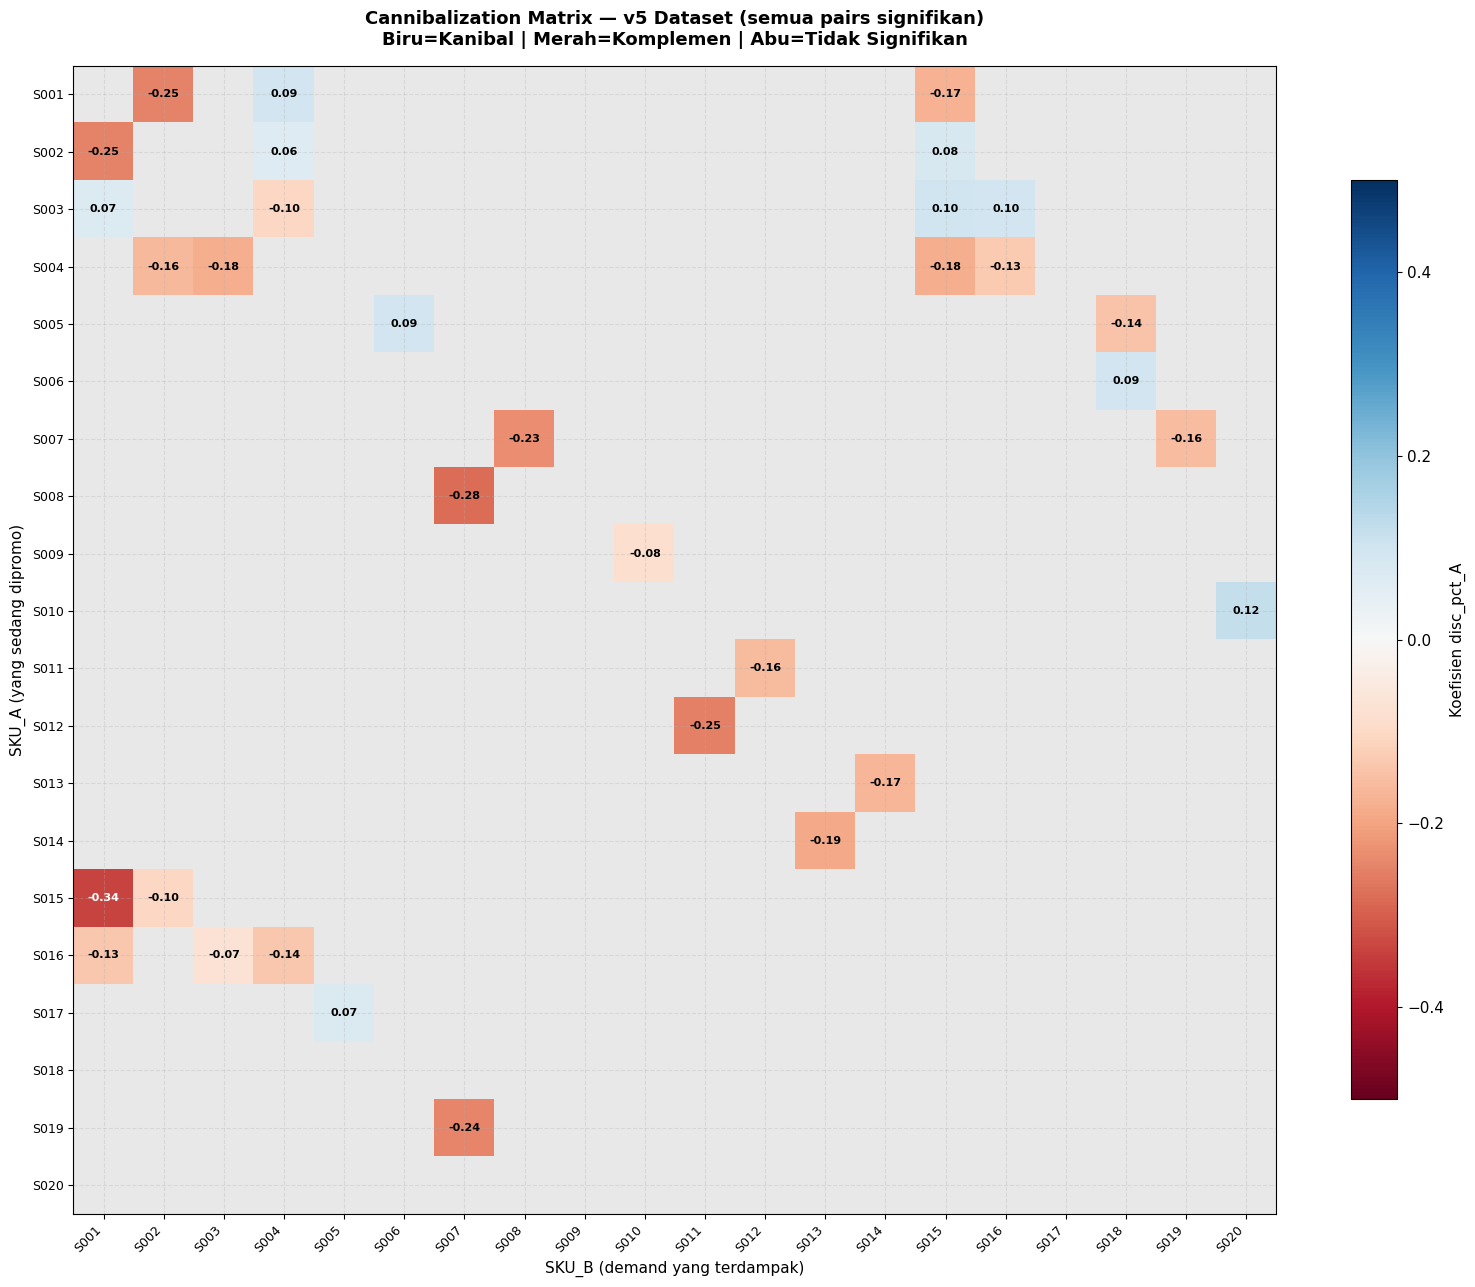

✅ Saved: 04_cannibalization_matrix.png


In [11]:
all_skus = sorted(set(results_df['SKU_A'].unique()) | set(results_df['SKU_B'].unique()))
matrix   = pd.DataFrame(np.nan, index=all_skus, columns=all_skus)

# Pakai semua pairs signifikan (reliable + unreliable) untuk gambaran lengkap,
# beri tanda berbeda untuk yang unreliable
for _, row in results_df.iterrows():
    if row['verdict'] != 'Tidak Signifikan':
        matrix.loc[row['SKU_A'], row['SKU_B']] = row['coef_disc_A']

fig, ax = plt.subplots(figsize=(16, 13))
cmap = plt.cm.RdBu
cmap.set_bad(color='#E8E8E8')
vals        = matrix.values.astype(float)
finite_vals = vals[np.isfinite(vals)]
vmax        = max(abs(finite_vals).max(), 0.5) if len(finite_vals) > 0 else 1.0

im = ax.imshow(vals, cmap=cmap, vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(all_skus)))
ax.set_yticks(range(len(all_skus)))
ax.set_xticklabels(all_skus, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(all_skus, fontsize=9)

for i, sa in enumerate(all_skus):
    for j, sb in enumerate(all_skus):
        val = matrix.loc[sa, sb]
        if not np.isnan(val):
            color = 'white' if abs(val) > vmax * 0.6 else 'black'
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                    fontsize=8, color=color, fontweight='bold')

ax.set_xlabel('SKU_B (demand yang terdampak)', fontsize=11)
ax.set_ylabel('SKU_A (yang sedang dipromo)', fontsize=11)
ax.set_title('Cannibalization Matrix — v5 Dataset (semua pairs signifikan)\nBiru=Kanibal | Merah=Komplemen | Abu=Tidak Signifikan',
             fontsize=13, fontweight='bold', pad=15)
plt.colorbar(im, ax=ax, label='Koefisien disc_pct_A', shrink=0.8)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '04_cannibalization_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 04_cannibalization_matrix.png')


In [12]:
daily_rev = df.groupby('SKU_ID')['Revenue'].mean().reset_index()
daily_rev.columns = ['SKU_ID','avg_daily_rev']

cannibal_pairs = reliable[reliable['verdict']=='CANNIBALIZATION'].copy()
impact_rows    = []

for _, row in cannibal_pairs.iterrows():
    rev_b      = daily_rev[daily_rev['SKU_ID']==row['SKU_B']]['avg_daily_rev'].values[0]
    pct_change = row['coef_disc_A'] * 0.10
    impact_rows.append({
        'SKU_Category'    : row['SKU_Category'],
        'SKU_A'           : row['SKU_A'], 'SKU_A_Name': row['SKU_A_Name'],
        'SKU_B'           : row['SKU_B'], 'SKU_B_Name': row['SKU_B_Name'],
        'coef_disc_A'     : row['coef_disc_A'],
        'p_value'         : row['p_value'],
        'avg_daily_rev_B' : round(rev_b, 0),
        'pct_qty_change'  : round(pct_change * 100, 2),
        'daily_rev_impact': round(rev_b * pct_change, 0),
    })

impact_df = pd.DataFrame(impact_rows)
if len(impact_df) > 0:
    impact_df = impact_df.sort_values('daily_rev_impact')
    display(impact_df[['SKU_Category','SKU_A_Name','SKU_B_Name',
                       'pct_qty_change','avg_daily_rev_B','daily_rev_impact']].reset_index(drop=True))
    print(f'\nTotal revenue at risk/hari : Rp{abs(impact_df["daily_rev_impact"].sum()):,.0f}')
else:
    print('Tidak ada pasangan RELIABLE dengan verdict CANNIBALIZATION.')

impact_df.to_csv(OUTPUT_DIR + 'revenue_impact.csv', index=False)
print('✅ Saved: revenue_impact.csv')


,SKU_Category,SKU_A_Name,SKU_B_Name,pct_qty_change,avg_daily_rev_B,daily_rev_impact
0,Minuman,Nabati Drinko Richoco 150ml,Nabati Drinko Richeese 150ml,-1.88,2048246.0,-38568.0
1,Extruded Snack,Richeese Siip Keju 20g,Richoco Ahh! Extruded 15g,-2.32,1037675.0,-24022.0
2,Kue/Pie,Nextar Brownies Pie 40g,Nextar Pineapple Pie 30g,-1.44,1671027.0,-23996.0
3,Wafer,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Pink Lava 50g,-1.80,1286287.0,-23205.0
4,Wafer,Richeese Wafer Keju 50g,Richeese Wafer Pink Lava 50g,-1.74,1286287.0,-22330.0
5,Wafer,Richoco Wafer Cokelat 10g Renceng,Richoco Wafer Hazelnut 50g,-1.32,1448626.0,-19122.0
6,Extruded Snack,Richeese Siip Keju 20g,Richeese Siip Jagung Bakar 20g,-1.55,681763.0,-10574.0
7,Mi Instan,Richeese Mi Instan Keju Pedas,Richeese Mi Instan Ramen Keju,-0.82,924123.0,-7596.0



Total revenue at risk/hari : Rp169,413
✅ Saved: revenue_impact.csv


In [13]:
from scipy import stats as scipy_stats

# ── Step 1: Baseline trend per SKU per Branch (dari hari IsPromo=0) ──────────
daily_panel = df.groupby(['Date','Branch','SKU_ID'])[['Qty']].sum().reset_index()
daily_panel = daily_panel.merge(
    df[['Date','Branch','SKU_ID','IsPromo']].drop_duplicates(),
    on=['Date','Branch','SKU_ID']
)
daily_panel['WeekNum'] = (daily_panel['Date'] - daily_panel['Date'].min()).dt.days // 7

baseline_results = []
for sku_id in sorted(daily_panel['SKU_ID'].unique()):
    for branch in daily_panel['Branch'].unique():
        sub = daily_panel[(daily_panel['SKU_ID']==sku_id) & (daily_panel['Branch']==branch)].sort_values('Date').copy()
        if len(sub) < 30: continue

        no_promo = sub[sub['IsPromo']==0]
        if len(no_promo) < 20: continue

        slope, intercept, r, p, se = scipy_stats.linregress(no_promo['WeekNum'], no_promo['Qty'])

        sub['BaselineDemand'] = (intercept + slope * sub['WeekNum']).clip(lower=1)
        sub['ResidualPct']    = (sub['Qty'] - sub['BaselineDemand']) / sub['BaselineDemand']
        baseline_results.append(sub)

daily_base = pd.concat(baseline_results, ignore_index=True)
print(f"Daily panel with baseline: {daily_base.shape}")
print(f"\nSample S001 Jakarta:")
print(daily_base[(daily_base['SKU_ID']=='S001') & (daily_base['Branch']=='Jakarta')]
      [['Date','IsPromo','Qty','BaselineDemand','ResidualPct']].head(5).to_string(index=False))


Daily panel with baseline: (58480, 8)

Sample S001 Jakarta:
      Date  IsPromo  Qty  BaselineDemand  ResidualPct
2024-01-01        0  483      834.653121    -0.421316
2024-01-02        0  883      834.653121     0.057925
2024-01-03        0  706      834.653121    -0.154140
2024-01-04        0  783      834.653121    -0.061886
2024-01-05        0  634      834.653121    -0.240403


In [14]:
# ── Step 2: DiD per pasangan SKU (sama kategori, dua arah) ────────────────────

did_results = []

for cat in sorted(df['SKU_Category'].unique()):
    skus = [s for s, c in sku_cat.items() if c == cat]
    if len(skus) < 2: continue

    for sku_a, sku_b in permutations(skus, 2):
        promo_a = (daily_base[daily_base['SKU_ID']==sku_a]
                   .groupby('Date')['IsPromo'].max().reset_index(name='IsPromo_A'))

        resid_b = daily_base[daily_base['SKU_ID']==sku_b][['Date','Branch','ResidualPct']].copy()
        merged  = resid_b.merge(promo_a, on='Date')

        if len(merged) < 30: continue

        treatment = merged[merged['IsPromo_A']==1]['ResidualPct']
        control   = merged[merged['IsPromo_A']==0]['ResidualPct']

        if len(treatment) < 5 or len(control) < 5: continue

        did = treatment.mean() - control.mean()
        t_stat, p_two = scipy_stats.ttest_ind(treatment, control)
        p_one = p_two/2 if t_stat < 0 else 1 - p_two/2

        did_results.append({
            'SKU_Category': cat,
            'SKU_A': sku_a, 'SKU_A_Name': sku_name[sku_a],
            'SKU_B': sku_b, 'SKU_B_Name': sku_name[sku_b],
            'N_Treatment': len(treatment), 'N_Control': len(control),
            'DiD': round(did, 4), 'DiD_Pct': round(did*100, 2),
            'T_stat': round(t_stat, 4), 'P_one': round(p_one, 4),
            'Significant': p_one < 0.05 and did < 0,
        })

did_df = pd.DataFrame(did_results)
sig_did = did_df[did_df['Significant']].sort_values('DiD')

print(f"Total pairs tested: {len(did_df)}")
print(f"Significant cannibalization (DiD<0, p<0.05): {len(sig_did)}")
print()
display(sig_did[['SKU_Category','SKU_A_Name','SKU_B_Name','DiD_Pct','P_one','N_Treatment','N_Control']].reset_index(drop=True))

did_df.to_csv(OUTPUT_DIR + 'did_results.csv', index=False)
print('\n✅ Saved: did_results.csv')


Total pairs tested: 58
Significant cannibalization (DiD<0, p<0.05): 27



,SKU_Category,SKU_A_Name,SKU_B_Name,DiD_Pct,P_one,N_Treatment,N_Control
0,Wafer,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 50g,-17.36,0.0000,852,2072
1,Wafer,Richeese Wafer Pink Lava 50g,Richeese Wafer Keju 50g,-17.35,0.0000,812,2112
2,Wafer,Richeese Wafer Keju 50g,Richoco Wafer Cokelat 50g,-10.17,0.0000,788,2136
3,Wafer,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 10g Renceng,-9.88,0.0000,852,2072
4,Wafer,Richoco Wafer Hazelnut 50g,Richeese Wafer Keju 50g,-9.35,0.0000,712,2212
5,Wafer,Richeese Wafer Keju 50g,Richeese Wafer Pink Lava 50g,-7.57,0.0000,788,2136
6,Wafer,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Pink Lava 50g,-7.39,0.0000,896,2028
7,Extruded Snack,Richeese Siip Keju 20g,Richoco Ahh! Extruded 15g,-7.36,0.0000,824,2100
8,Wafer,Richoco Wafer Cokelat 10g Renceng,Richoco Wafer Hazelnut 50g,-6.85,0.0000,896,2028
9,Wafer,Richoco Wafer Hazelnut 50g,Richoco Wafer Cokelat 10g Renceng,-6.76,0.0000,712,2212



✅ Saved: did_results.csv


In [15]:
# ── Step 3: Compare OLS vs DiD untuk pairs yang sama ──────────────────────────

comparison = results_df[['SKU_Category','SKU_A','SKU_A_Name','SKU_B','SKU_B_Name',
                          'coef_disc_A','p_value','verdict','reliability']].merge(
    did_df[['SKU_A','SKU_B','DiD_Pct','P_one','Significant']],
    on=['SKU_A','SKU_B'], how='left'
)
comparison['DiD_Verdict'] = comparison['Significant'].map(
    {True: 'CANNIBALIZATION', False: 'Tidak Signifikan'}
)

print("=== Pasangan dengan KEDUA method (OLS & DiD) signifikan cannibalization ===")
both_sig = comparison[(comparison['verdict']=='CANNIBALIZATION') & (comparison['DiD_Verdict']=='CANNIBALIZATION')]
display(both_sig[['SKU_Category','SKU_A_Name','SKU_B_Name',
                   'coef_disc_A','p_value','DiD_Pct','P_one','reliability']].reset_index(drop=True))

print(f"\n=== Summary Cross-Validation ===")
print(f"OLS CANNIBALIZATION (semua)      : {(comparison['verdict']=='CANNIBALIZATION').sum()}")
print(f"DiD CANNIBALIZATION (signifikan) : {(comparison['DiD_Verdict']=='CANNIBALIZATION').sum()}")
print(f"KEDUA method setuju               : {len(both_sig)}")

print(f"\n=== Pasangan OLS signifikan tapi DiD TIDAK (perlu hati-hati) ===")
ols_only = comparison[(comparison['verdict']=='CANNIBALIZATION') & (comparison['DiD_Verdict']!='CANNIBALIZATION')]
display(ols_only[['SKU_Category','SKU_A_Name','SKU_B_Name','coef_disc_A','p_value','DiD_Pct','P_one']].reset_index(drop=True))

comparison.to_csv(OUTPUT_DIR + 'ols_vs_did_comparison.csv', index=False)
print('\n✅ Saved: ols_vs_did_comparison.csv')


=== Pasangan dengan KEDUA method (OLS & DiD) signifikan cannibalization ===


,SKU_Category,SKU_A_Name,SKU_B_Name,coef_disc_A,p_value,DiD_Pct,P_one,reliability
0,Biskuit,Nabati Biskuit Rasa Kelapa,Nabati Biskuit Rasa Cokelat,-0.1583,0.0000,-5.96,0.0000,UNRELIABLE
1,Biskuit,Nabati Biskuit Rasa Cokelat,Nabati Biskuit Rasa Kelapa,-0.2528,0.0000,-5.45,0.0000,UNRELIABLE
2,Extruded Snack,Richeese Siip Keju 20g,Richoco Ahh! Extruded 15g,-0.2315,0.0000,-7.36,0.0000,RELIABLE
3,Extruded Snack,Richeese Siip Keju 20g,Richeese Siip Jagung Bakar 20g,-0.1551,0.0000,-3.50,0.0032,RELIABLE
4,Extruded Snack,Richeese Siip Jagung Bakar 20g,Richeese Siip Keju 20g,-0.2444,0.0000,-5.07,0.0000,UNRELIABLE
5,Kue/Pie,Nextar Brownies Pie 40g,Nextar Pineapple Pie 30g,-0.1436,0.0000,-2.87,0.0143,RELIABLE
6,Minuman,Nabati Drinko Richeese 150ml,Nabati Drinko Richoco 150ml,-0.1659,0.0000,-4.02,0.0016,UNRELIABLE
7,Wafer,Richeese Wafer Keju 50g,Richoco Wafer Cokelat 50g,-0.2465,0.0000,-10.17,0.0000,UNRELIABLE
8,Wafer,Richeese Wafer Keju 50g,Richeese Wafer Pink Lava 50g,-0.1736,0.0000,-7.57,0.0000,RELIABLE
9,Wafer,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 50g,-0.2478,0.0000,-17.36,0.0000,UNRELIABLE



=== Summary Cross-Validation ===
OLS CANNIBALIZATION (semua)      : 23
DiD CANNIBALIZATION (signifikan) : 27
KEDUA method setuju               : 16

=== Pasangan OLS signifikan tapi DiD TIDAK (perlu hati-hati) ===


,SKU_Category,SKU_A_Name,SKU_B_Name,coef_disc_A,p_value,DiD_Pct,P_one
0,Extruded Snack,Richoco Ahh! Extruded 15g,Richeese Siip Keju 20g,-0.2776,0.0000,-1.96,0.0539
1,Mi Instan,Richeese Mi Instan Keju Pedas,Richeese Mi Instan Ramen Keju,-0.0822,0.0093,3.26,0.9963
2,Minuman,Nabati Drinko Richoco 150ml,Nabati Drinko Richeese 150ml,-0.1883,0.0000,3.97,0.9973
3,Wafer,Richeese Wafer Keju 10g Renceng,Richoco Wafer Cokelat 10g Renceng,-0.1044,0.0002,0.91,0.7701
4,Wafer,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Keju 10g Renceng,-0.1832,0.0000,-1.83,0.0750
5,Wafer,Richeese Wafer Pink Lava 50g,Richoco Wafer Cokelat 50g,-0.1018,0.0129,12.32,1.0000
6,Wafer,Richoco Wafer Hazelnut 50g,Richeese Wafer Keju 10g Renceng,-0.0736,0.0317,0.15,0.5431



✅ Saved: ols_vs_did_comparison.csv


In [16]:
daily = df.groupby(['Date','SKU_ID','SKU_Name','SKU_Category'])[['Qty','Revenue']].sum().reset_index()

train_end      = pd.Timestamp('2025-09-30')
forecast_start = pd.Timestamp('2025-10-01')
forecast_end   = pd.Timestamp('2025-12-31')

skus             = sorted(daily['SKU_ID'].unique())
forecast_results = []
evaluation       = []

print('Training Prophet models...')
for sku in skus:
    sku_data = daily[daily['SKU_ID']==sku][['Date','Qty','Revenue']].copy()
    sku_name_val = daily[daily['SKU_ID']==sku]['SKU_Name'].iloc[0]
    sku_cat_val  = daily[daily['SKU_ID']==sku]['SKU_Category'].iloc[0]

    train   = sku_data[sku_data['Date'] <= train_end].rename(columns={'Date':'ds','Qty':'y'})
    actuals = sku_data[(sku_data['Date'] >= forecast_start) & (sku_data['Date'] <= forecast_end)]

    if len(train) < 100: continue

    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.05,
        interval_width=0.95,
    )
    m.fit(train[['ds','y']])

    future   = m.make_future_dataframe(periods=92)
    forecast = m.predict(future)

    fc_period = forecast[forecast['ds'] >= forecast_start][['ds','yhat','yhat_lower','yhat_upper']].copy()
    fc_period['SKU_ID']       = sku
    fc_period['SKU_Name']     = sku_name_val
    fc_period['SKU_Category'] = sku_cat_val

    avg_price = sku_data['Revenue'].sum() / sku_data['Qty'].sum()
    fc_period['qty_forecast']     = fc_period['yhat'].clip(lower=0).round(0).astype(int)
    fc_period['qty_lower']        = fc_period['yhat_lower'].clip(lower=0).round(0).astype(int)
    fc_period['qty_upper']        = fc_period['yhat_upper'].clip(lower=0).round(0).astype(int)
    fc_period['revenue_forecast'] = (fc_period['qty_forecast'] * avg_price).round(0)
    forecast_results.append(fc_period)

    if len(actuals) > 0:
        fc_eval = forecast[forecast['ds'].isin(actuals['Date'])][['ds','yhat']].copy()
        merged  = actuals.rename(columns={'Date':'ds'}).merge(fc_eval, on='ds')
        if len(merged) > 0:
            mape = (abs(merged['Qty'] - merged['yhat']) / merged['Qty']).mean() * 100
            evaluation.append({
                'SKU_ID': sku, 'SKU_Name': sku_name_val,
                'MAPE_pct': round(mape, 2), 'n_days': len(merged),
            })

    print(f'  ✓ {sku} done')

forecast_df = pd.concat(forecast_results, ignore_index=True)
eval_df     = pd.DataFrame(evaluation).sort_values('MAPE_pct')

print(f'\n✅ All models done')


Training Prophet models...


10:30:05 - cmdstanpy - INFO - Chain [1] start processing
10:30:06 - cmdstanpy - INFO - Chain [1] done processing
10:30:06 - cmdstanpy - INFO - Chain [1] start processing


  ✓ S001 done


10:30:07 - cmdstanpy - INFO - Chain [1] done processing
10:30:07 - cmdstanpy - INFO - Chain [1] start processing
10:30:07 - cmdstanpy - INFO - Chain [1] done processing


  ✓ S002 done


...

  ✓ S017 done


10:30:12 - cmdstanpy - INFO - Chain [1] start processing
10:30:12 - cmdstanpy - INFO - Chain [1] done processing


  ✓ S018 done


10:30:12 - cmdstanpy - INFO - Chain [1] start processing
10:30:12 - cmdstanpy - INFO - Chain [1] done processing


  ✓ S019 done
  ✓ S020 done

✅ All models done


In [17]:
print('=== FORECAST EVALUATION (MAPE) ===')
display(eval_df.reset_index(drop=True))
print(f'\nAvg MAPE : {eval_df["MAPE_pct"].mean():.2f}%')
print(f'Min MAPE : {eval_df["MAPE_pct"].min():.2f}% ({eval_df.iloc[0]["SKU_ID"]})')
print(f'Max MAPE : {eval_df["MAPE_pct"].max():.2f}% ({eval_df.iloc[-1]["SKU_ID"]})')

forecast_df.to_csv(OUTPUT_DIR + 'timeseries_forecast.csv', index=False)
eval_df.to_csv(OUTPUT_DIR + 'forecast_evaluation.csv', index=False)
print('\n✅ Saved: timeseries_forecast.csv, forecast_evaluation.csv')


=== FORECAST EVALUATION (MAPE) ===


,SKU_ID,SKU_Name,MAPE_pct,n_days
0,S003,Richeese Wafer Keju 10g Renceng,11.06,92
1,S005,Nextar Brownies Pie 40g,11.54,92
2,S014,Nabati Drinko Richoco 150ml,11.92,92
3,S009,Richeese Mi Instan Keju Pedas,12.61,92
4,S008,Richoco Ahh! Extruded 15g,13.31,92
5,S010,Richeese Mi Instan Ramen Keju,14.19,92
6,S012,Nabati Biskuit Rasa Cokelat,14.25,92
7,S011,Nabati Biskuit Rasa Kelapa,14.27,92
8,S007,Richeese Siip Keju 20g,14.32,92
9,S017,Nextar Choco Delight 40g,14.34,92



Avg MAPE : 15.65%
Min MAPE : 11.06% (S003)
Max MAPE : 22.02% (S013)

✅ Saved: timeseries_forecast.csv, forecast_evaluation.csv


In [18]:
# Q4 2025 Revenue Forecast Summary
forecast_df['Month'] = pd.to_datetime(forecast_df['ds']).dt.month
q4_monthly = forecast_df.groupby(['SKU_ID','SKU_Name','SKU_Category','Month'])[
    ['qty_forecast','revenue_forecast']].sum().reset_index()

q4_summary = q4_monthly.groupby(['SKU_ID','SKU_Name','SKU_Category']).agg(
    qty_q4    = ('qty_forecast','sum'),
    rev_q4    = ('revenue_forecast','sum')
).reset_index().sort_values('rev_q4', ascending=False)

print('=== Q4 2025 REVENUE FORECAST per SKU ===')
q4_display = q4_summary.copy()
q4_display['rev_q4_fmt'] = q4_display['rev_q4'].apply(lambda x: f'Rp{x/1e9:.2f}B')
display(q4_display[['SKU_ID','SKU_Name','SKU_Category','qty_q4','rev_q4_fmt']].reset_index(drop=True))


=== Q4 2025 REVENUE FORECAST per SKU ===


,SKU_ID,SKU_Name,SKU_Category,qty_q4,rev_q4_fmt
0,S001,Richeese Wafer Keju 50g,Wafer,258701,Rp1.43B
1,S003,Richeese Wafer Keju 10g Renceng,Wafer,118043,Rp1.04B
2,S004,Richoco Wafer Cokelat 10g Renceng,Wafer,113221,Rp1.02B
3,S013,Nabati Drinko Richeese 150ml,Minuman,257452,Rp0.92B
4,S005,Nextar Brownies Pie 40g,Kue/Pie,114072,Rp0.87B
5,S018,Nextar Pineapple Pie 30g,Kue/Pie,122300,Rp0.77B
6,S006,Nextar Nastar Pie 30g,Kue/Pie,118599,Rp0.76B
7,S017,Nextar Choco Delight 40g,Kue/Pie,111629,Rp0.71B
8,S016,Richoco Wafer Hazelnut 50g,Wafer,117470,Rp0.65B
9,S002,Richoco Wafer Cokelat 50g,Wafer,109615,Rp0.57B


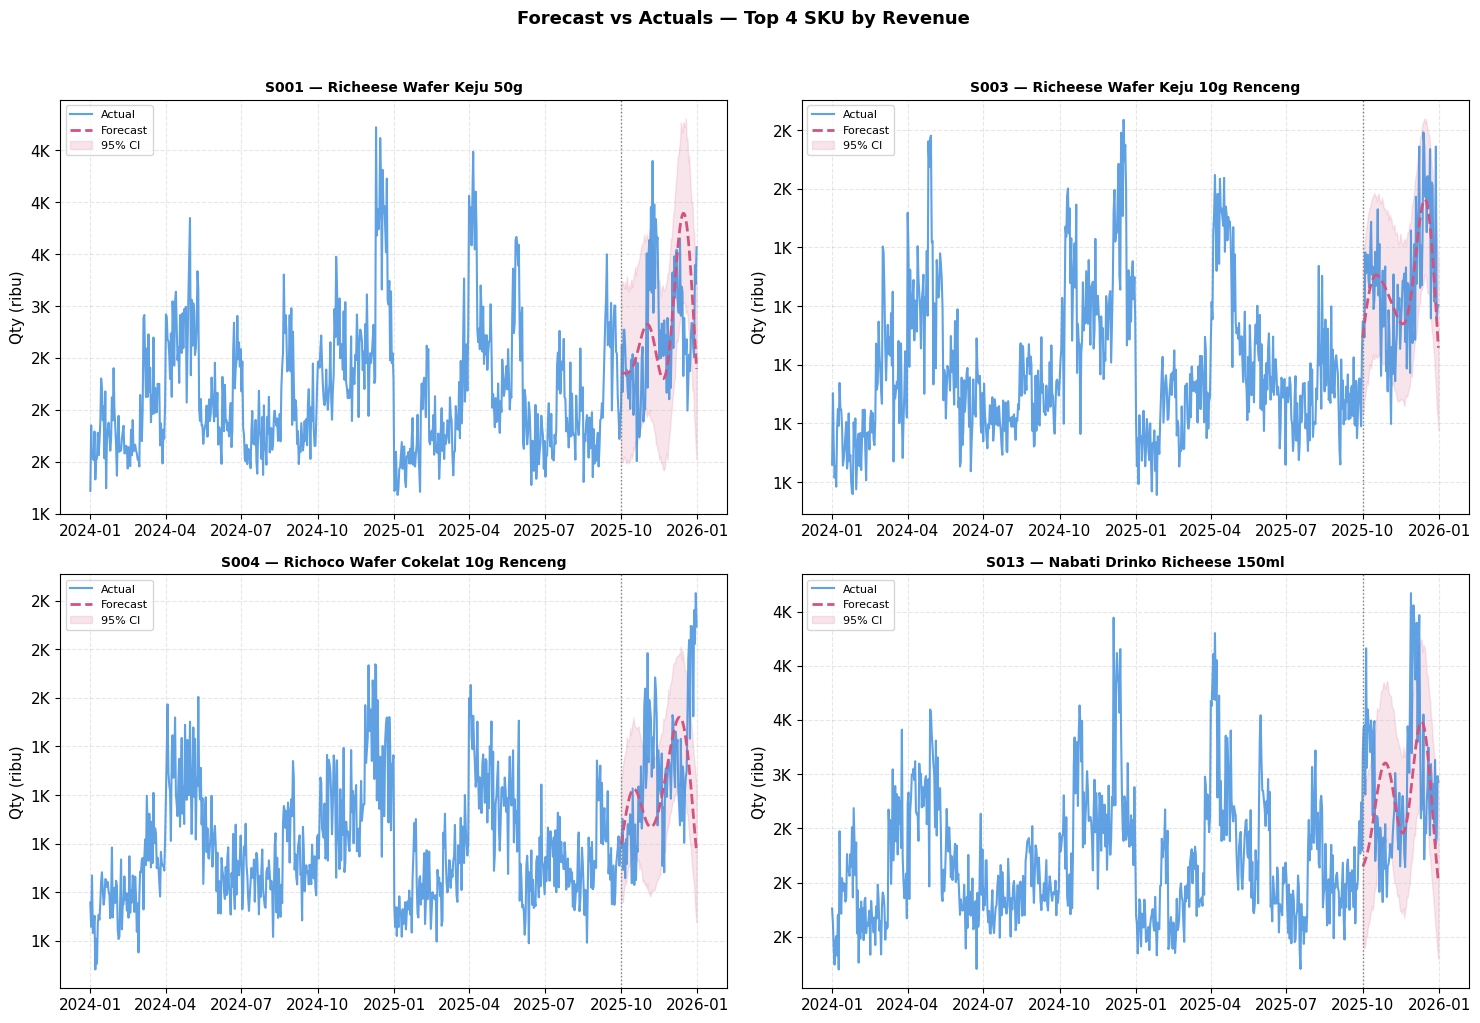

✅ Saved: 05_forecast_vs_actuals.png


In [19]:
# Visualisasi forecast vs actuals untuk top 4 SKU
top4_skus = q4_summary.head(4)['SKU_ID'].tolist()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for idx, sku in enumerate(top4_skus):
    ax  = axes[idx]
    sku_name_val = daily[daily['SKU_ID']==sku]['SKU_Name'].iloc[0]
    sku_hist     = daily[daily['SKU_ID']==sku][['Date','Qty']].copy()
    sku_fc       = forecast_df[forecast_df['SKU_ID']==sku].copy()
    sku_fc['ds'] = pd.to_datetime(sku_fc['ds'])

    ax.plot(sku_hist['Date'], sku_hist['Qty']/1000, color='#378ADD', linewidth=1.5, label='Actual', alpha=0.8)
    ax.plot(sku_fc['ds'], sku_fc['qty_forecast']/1000, color='#D4537E', linewidth=2,
            linestyle='--', label='Forecast')
    ax.fill_between(sku_fc['ds'], sku_fc['qty_lower']/1000, sku_fc['qty_upper']/1000,
                    color='#D4537E', alpha=0.15, label='95% CI')

    ax.axvline(pd.Timestamp('2025-10-01'), color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'{sku} — {sku_name_val}', fontsize=10, fontweight='bold')
    ax.set_ylabel('Qty (ribu)')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:.0f}K'))
    ax.legend(fontsize=8)

plt.suptitle('Forecast vs Actuals — Top 4 SKU by Revenue', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + '05_forecast_vs_actuals.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 05_forecast_vs_actuals.png')


In [20]:
print('=' * 65)
print('RINGKASAN HASIL ANALISIS v5')
print('=' * 65)

print(f'\n--- Dataset ---')
print(f'Periode         : {df["Date"].min().date()} → {df["Date"].max().date()}')
print(f'Total rows      : {len(df):,}')
print(f'SKU             : {df["SKU_ID"].nunique()}')
print(f'Branch          : {df["Branch"].nunique()}')
print(f'Promo days (avg): {(df["IsPromo"].mean()*100):.1f}%')

print(f'\n--- Cannibalization ---')
print(f'Total pasangan reliable  : {len(reliable)}')
print(f'CANNIBALIZATION detected : {(reliable["verdict"]=="CANNIBALIZATION").sum()}')
print(f'KOMPLEMEN detected       : {(reliable["verdict"]=="KOMPLEMEN").sum()}')
print(f'CANNIBALIZATION (semua, termasuk unreliable): {(results_df["verdict"]=="CANNIBALIZATION").sum()}')
if len(impact_df) > 0:
    print(f'Total revenue at risk    : Rp{abs(impact_df["daily_rev_impact"].sum()):,.0f}/hari')
    print(f'Worst pair               : {impact_df.iloc[0]["SKU_A_Name"]} → {impact_df.iloc[0]["SKU_B_Name"]}')

print(f'\n--- Time Series ---')
print(f'Avg MAPE        : {eval_df["MAPE_pct"].mean():.2f}%')
total_q4_rev = q4_summary["rev_q4"].sum()
print(f'Total Q4 2025   : Rp{total_q4_rev/1e9:.2f}B projected revenue')

print(f'\n--- Output Files ---')
for f in ['cannibalization_results.csv','revenue_impact.csv',
          'timeseries_forecast.csv','forecast_evaluation.csv',
          '01_monthly_trend.png','02_price_cv.png','03_promo_calendar.png',
          '04_cannibalization_matrix.png','05_forecast_vs_actuals.png']:
    print(f'  {OUTPUT_DIR}{f}')

print('\n✅ Analisis selesai')


RINGKASAN HASIL ANALISIS v5

--- Dataset ---
Periode         : 2024-01-01 → 2025-12-31
Total rows      : 58,480
SKU             : 20
Branch          : 4
Promo days (avg): 28.2%

--- Cannibalization ---
Total pasangan reliable  : 21
CANNIBALIZATION detected : 8
KOMPLEMEN detected       : 4
CANNIBALIZATION (semua, termasuk unreliable): 23
Total revenue at risk    : Rp169,413/hari
Worst pair               : Nabati Drinko Richoco 150ml → Nabati Drinko Richeese 150ml

--- Time Series ---
Avg MAPE        : 15.65%
Total Q4 2025   : Rp13.00B projected revenue

--- Output Files ---
  analysis_output_v5/cannibalization_results.csv
  analysis_output_v5/revenue_impact.csv
  analysis_output_v5/timeseries_forecast.csv
  analysis_output_v5/forecast_evaluation.csv
  analysis_output_v5/01_monthly_trend.png
  analysis_output_v5/02_price_cv.png
  analysis_output_v5/03_promo_calendar.png
  analysis_output_v5/04_cannibalization_matrix.png
  analysis_output_v5/05_forecast_vs_actuals.png

✅ Analisis selesai
